# 02 — Model Training & Evaluation
Train the FRAUDSCOPE AI classifier, evaluate it the way imbalanced problems must be
evaluated, and save the artefacts the dashboard loads.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
os.chdir("..")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, roc_curve, confusion_matrix,
                             classification_report, average_precision_score, roc_auc_score)

from src.preprocessing import build_events
from src.features import build_features
from src.model import time_split, build_model, evaluate

## 1. Data → features

In [2]:
events = build_events(use_synthetic=True)
X, y, profiles = build_features(events)
X.head()

[preprocessing] no raw CSV found -> generating synthetic data
[preprocessing] wrote data\processed\events.csv (52,274 rows, fraud rate 2.988%)
[features] built 52,274 x 11 feature matrix


,log_amount,amount_ratio,amount_zscore,hour,is_night,seconds_since_prev,txn_count_10min,txn_count_1h,is_new_device,is_new_location,user_txn_index
0,10.102169,0.999959,0.000000,1,1,86400.0,1,1,0,0,0
1,7.163498,0.999226,0.000000,8,0,86400.0,1,1,0,0,0
2,7.063211,0.903804,-123.230000,10,0,5507.0,1,1,0,1,1
3,6.946966,0.999038,0.000000,10,0,86400.0,1,1,0,0,0
4,8.561769,4.250202,63.852352,11,0,3308.0,1,2,1,0,2


## 2. Chronological split
A random split would leak a customer's future behaviour into the training set.

In [3]:
X_train, X_test, y_train, y_test = time_split(X, y, test_size=0.2)
pos = int(y_train.sum()); pos_weight = (len(y_train) - pos) / pos
print(f"train {len(X_train):,} | test {len(X_test):,} | fraud in train {y_train.mean():.3%}")

train 41,819 | test 10,455 | fraud in train 3.054%


## 3. Train

In [4]:
model = build_model(pos_weight)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]

## 4. Evaluate — precision, recall, F1, PR-AUC, confusion matrix

In [5]:
metrics = evaluate(model, X_test, y_test)
metrics

{'n_test': 10455,
 'fraud_rate_test': 0.027259684361549498,
 'threshold': 0.8921,
 'precision': 0.5,
 'recall': 0.4737,
 'f1': 0.4865,
 'pr_auc': 0.4712,
 'roc_auc': 0.9393,
 'confusion_matrix': [[10035, 135], [150, 135]]}

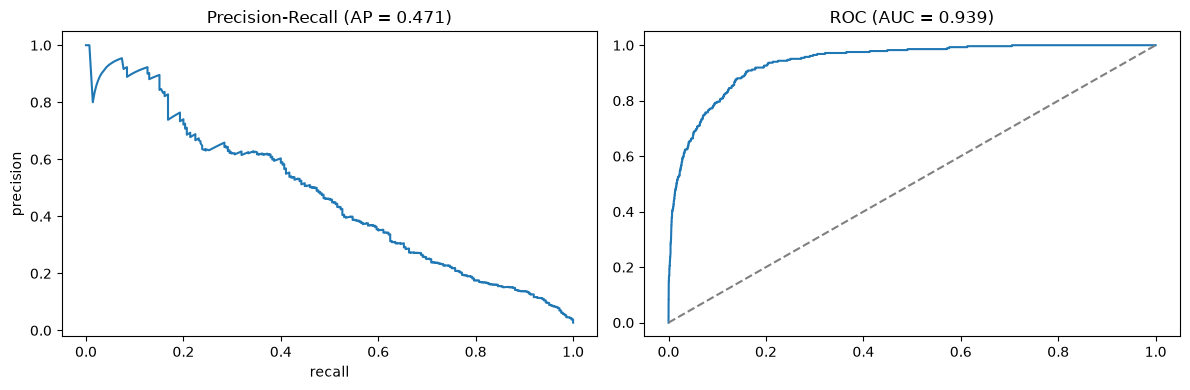

In [6]:
prec, rec, thr = precision_recall_curve(y_test, proba)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec); axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title(f"Precision-Recall (AP = {average_precision_score(y_test, proba):.3f})")
fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr); axes[1].plot([0, 1], [0, 1], "--", color="gray")
axes[1].set_title(f"ROC (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.tight_layout(); plt.show()

### Choosing the threshold
The operating point is picked from the PR curve (best F1), not left at 0.5. In production this
choice is a business decision: how many false alarms can the review team absorb?

In [7]:
pred = (proba >= metrics["threshold"]).astype(int)
print(classification_report(y_test, pred, digits=3, zero_division=0))
pd.DataFrame(confusion_matrix(y_test, pred),
             index=["actual legit", "actual fraud"],
             columns=["pred legit", "pred fraud"])

              precision    recall  f1-score   support

           0      0.985     0.987     0.986     10170
           1      0.500     0.474     0.486       285

    accuracy                          0.973     10455
   macro avg      0.743     0.730     0.736     10455
weighted avg      0.972     0.973     0.972     10455



,pred legit,pred fraud
actual legit,10035,135
actual fraud,150,135


## 5. Which signals matter

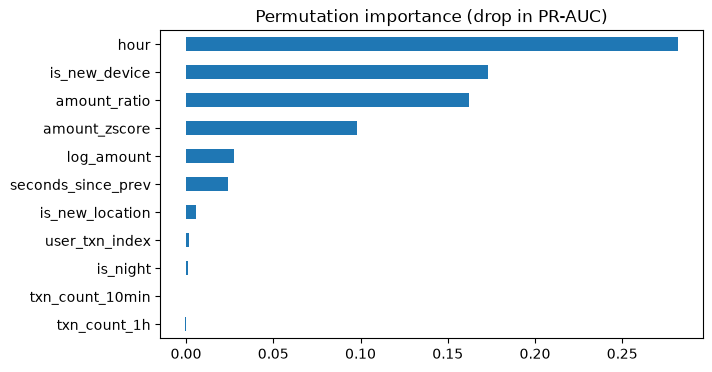

In [8]:
from src.model import permutation_importance_fast
sample = X_test.sample(min(len(X_test), 15000), random_state=0)
imp = permutation_importance_fast(model, sample, y_test.loc[sample.index])
pd.Series(imp).sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Permutation importance (drop in PR-AUC)"); plt.show()

## 6. Save artefacts and test the full scoring path

In [4]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

print("Project path added successfully!")

Project path added successfully!


In [5]:
from src.model import train

model, metrics = train(use_synthetic=True)

print("================================")
print("MODEL TRAINED SUCCESSFULLY!")
print("================================")
print("Metrics:")
print(metrics) # writes models/fraud_model.pkl + metrics.json

[preprocessing] no raw CSV found -> generating synthetic data
[preprocessing] wrote data\processed\events.csv (52,274 rows, fraud rate 2.988%)
[features] built 52,274 x 11 feature matrix
[model] train=41,819  test=10,455  fraud in train=3.054%  pos_weight=31.7
{
  "n_test": 10455,
  "fraud_rate_test": 0.027259684361549498,
  "threshold": 0.906,
  "precision": 0.5642,
  "recall": 0.4316,
  "f1": 0.4891,
  "pr_auc": 0.4747,
  "roc_auc": 0.9397,
  "confusion_matrix": [
    [
      10075,
      95
    ],
    [
      162,
      123
    ]
  ]
}
[model] saved models\fraud_model.pkl and models\metrics.json
MODEL TRAINED SUCCESSFULLY!
Metrics:
{'n_test': 10455, 'fraud_rate_test': 0.027259684361549498, 'threshold': 0.906, 'precision': 0.5642, 'recall': 0.4316, 'f1': 0.4891, 'pr_auc': 0.4747, 'roc_auc': 0.9397, 'confusion_matrix': [[10075, 95], [162, 123]], 'feature_importance': {'hour': 0.27854, 'is_new_device': 0.17934, 'amount_ratio': 0.17712, 'amount_zscore': 0.08803, 'seconds_since_prev': 0.

In [10]:
from src.predictor import FraudScope
fs = FraudScope.load()
res = fs.score({"amount": 85000, "hour": 2, "location": "Delhi", "device_id": "unknown-device",
                "txn_count_10min": 7, "seconds_since_prev": 45,
                "is_new_device": 1, "is_new_location": 1})
print(res["summary"])
for r in res["reasons"]:
    print(f"  +{r['points']:>5}  {r['signal']}: {r['detail']}")

Risk 94/100 (HIGH). Flagged because of unusually high amount; high transaction velocity; new device; location deviation. Recommended action: Hold for additional verification and route to a fraud analyst.
  + 54.4  Model pattern similarity: The model rates this transaction 90.6% similar to known fraudulent behaviour.
  +  8.9  Unusually high amount: Rs 85,000 is about 34.0x this customer's usual transaction size.
  +  7.6  High transaction velocity: 7 transactions from this account within 10 minutes.
  +  6.3  New device: The transaction came from a device never used by this customer before.
  +  6.3  Location deviation: Transaction originates from Delhi, outside the customer's usual locations.
  +  5.1  Unusual transaction time: Executed at 02:00, inside the customer's normal inactive window.
  +  3.2  Rapid repeat transaction: Only 45s since the previous transaction.
  +  2.5  Thin customer history: Very little past activity, so behavioural baselines are weak.


In [1]:
import sys
import sklearn

print("Python:")
print(sys.executable)

print("\nScikit-learn:")
print(sklearn.__version__)

Python:
c:\Users\user\Downloads\FRAUDSCOPE-AI\FRAUDSCOPE-AI\venv\Scripts\python.exe

Scikit-learn:
1.9.1


In [6]:
from src.predictor import FraudScope

fs = FraudScope.load()

print("================================")
print("MODEL LOADED SUCCESSFULLY!")
print("================================")

res = fs.score({
    "amount": 85000,
    "hour": 2,
    "location": "Delhi",
    "device_id": "unknown-device",
    "txn_count_10min": 7,
    "seconds_since_prev": 45,
    "is_new_device": 1,
    "is_new_location": 1
})

print("\nRESULT:")
print(res["summary"])

print("\nREASONS:")
for r in res["reasons"]:
    print(f"+{r['points']:>5}  {r['signal']}: {r['detail']}")

MODEL LOADED SUCCESSFULLY!

RESULT:
Risk 97/100 (HIGH). Flagged because of unusually high amount; high transaction velocity; new device; location deviation. Recommended action: Hold for additional verification and route to a fraud analyst.

REASONS:
+ 57.0  Model pattern similarity: The model rates this transaction 95.0% similar to known fraudulent behaviour.
+  8.9  Unusually high amount: Rs 85,000 is about 34.0x this customer's usual transaction size.
+  7.6  High transaction velocity: 7 transactions from this account within 10 minutes.
+  6.3  New device: The transaction came from a device never used by this customer before.
+  6.3  Location deviation: Transaction originates from Delhi, outside the customer's usual locations.
+  5.1  Unusual transaction time: Executed at 02:00, inside the customer's normal inactive window.
+  3.2  Rapid repeat transaction: Only 45s since the previous transaction.
+  2.5  Thin customer history: Very little past activity, so behavioural baselines are 